# 01 · Análisis Exploratorio de Datos (EDA)

**Proyecto:** TP Churn de Clientes · IAAN
**Dataset:** `data/raw/E_Commerce_Dataset.xlsx` (hoja `E Comm`) · 5.630 filas · 20 columnas
**Target:** `Churn` (1 = el cliente se fue · 0 = se quedó) · tasa global ≈ 16,8%
**Fecha:** 2026-06-05

Este notebook es la **versión ejecutable** del EDA. Los hallazgos en prosa
están en `reports/eda.md`, las hipótesis validadas en `reports/hipotesis.md`,
y los problemas de datos en `reports/data_quality.md`.

**Orden:**
1. Carga + perfilado básico
2. Análisis del target (desbalance)
3. Features numéricas (distribución, normalidad, asociación con churn, outliers)
4. Features categóricas (cardinalidad, asociación con churn, categorías raras)
5. Detección de leakage (foco en `Complain`)
6. Validación de las 5 hipótesis del proyecto
7. Gráficos adicionales (concentración del churn por tenure, top segmentos, cashback)
8. Conclusiones y handoff al Modeler

Las funciones de carga/limpieza viven en `src/data_prep.py`; este notebook las consume.


In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Si el notebook se abre desde notebooks/, volver al root para que paths relativos funcionen
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

from src.data_prep import (
    load_clean, NUMERIC_COLS, CATEGORICAL_COLS, TARGET, ID_COL,
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.autolayout": True})
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

FIG_DIR = Path("reports") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Working directory:", Path.cwd())


Working directory: /Users/francovieyramerigo/Desktop/Proyectos-Personales/tp-churn-ecommerce


## 1 · Carga + perfilado básico

In [2]:
df = load_clean()
print("Shape:", df.shape)
df.head()


Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
# Dtypes y memoria
print("Memoria (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))
df.dtypes.to_frame("dtype")


Memoria (MB): 2.41


,dtype
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [4]:
# Nulos por columna
nulos = (df.isna().sum()
            .rename("n_nulos").to_frame()
            .assign(pct=lambda d: (d["n_nulos"] / len(df) * 100).round(2))
            .sort_values("n_nulos", ascending=False))
nulos[nulos["n_nulos"] > 0]


,n_nulos,pct
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


In [5]:
# Duplicados
print("Duplicados exactos (con CustomerID):", df.duplicated().sum())
print("Duplicados ignorando CustomerID :", df.drop(columns=[ID_COL]).duplicated().sum())


Duplicados exactos (con CustomerID): 0
Duplicados ignorando CustomerID : 557


**Lectura.** Hay 557 pares duplicados al ignorar `CustomerID`. Como casi todas las
features son discretas/baja-cardinalidad, son colisiones esperables — no
es error de carga (detalle en `reports/data_quality.md`). No se dropean.


In [6]:
# Columnas categóricas — value counts (categorías ya unificadas en data_prep.clean_categories)
for c in CATEGORICAL_COLS:
    print(c, "->", dict(df[c].value_counts()))


PreferredLoginDevice -> {'Mobile Phone': np.int64(3996), 'Computer': np.int64(1634)}
PreferredPaymentMode -> {'Debit Card': np.int64(2314), 'Credit Card': np.int64(1774), 'E wallet': np.int64(614), 'COD': np.int64(514), 'UPI': np.int64(414)}
Gender -> {'Male': np.int64(3384), 'Female': np.int64(2246)}
PreferedOrderCat -> {'Mobile Phone': np.int64(2080), 'Laptop & Accessory': np.int64(2050), 'Fashion': np.int64(826), 'Grocery': np.int64(410), 'Others': np.int64(264)}
MaritalStatus -> {'Married': np.int64(2986), 'Single': np.int64(1796), 'Divorced': np.int64(848)}


## 2 · Target — desbalance

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.16
1    16.84
Name: proportion, dtype: float64

Ratio minoritaria/mayoritaria: 0.202


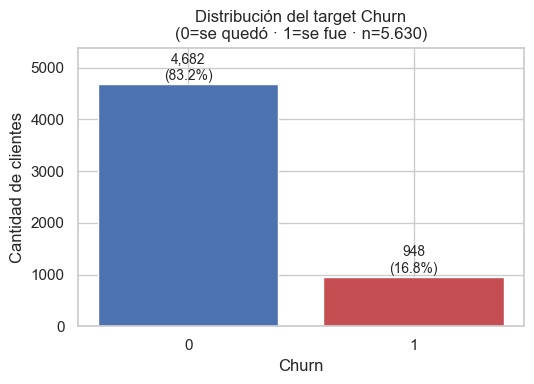

In [7]:
vc = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
print(vc); print(pct.round(2))
print("\nRatio minoritaria/mayoritaria:", round(vc.min() / vc.max(), 3))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar([str(i) for i in vc.index], vc.values, color=["#4C72B0", "#C44E52"])
for i, (n, p) in enumerate(zip(vc.values, pct.values)):
    ax.text(i, n + 30, f"{n:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribución del target Churn\n(0=se quedó · 1=se fue · n=5.630)")
ax.set_xlabel("Churn"); ax.set_ylabel("Cantidad de clientes")
ax.set_ylim(0, vc.max() * 1.15)
plt.show()


**Implicación para el modelado.** Con un desbalance ~1:5 y un costo asimétrico
(perder un cliente cuesta más que un falso positivo), no usamos **accuracy**
como métrica principal: el baseline "predecir siempre 0" da 83% sin hacer
nada útil. Métricas prioritarias: **recall** y **PR-AUC**.


## 3 · Features numéricas

In [8]:
num_cols = [c for c in NUMERIC_COLS if c != TARGET]

# Estadísticas descriptivas + asociación con churn (Mann-Whitney + rank-biserial)
rows = []
for c in num_cols:
    s = df[c]
    g0 = df.loc[df[TARGET] == 0, c].dropna()
    g1 = df.loc[df[TARGET] == 1, c].dropna()
    mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    rbc = 1 - 2 * mw.statistic / (len(g0) * len(g1))
    # KS normality test
    z = (s.dropna() - s.dropna().mean()) / (s.dropna().std() + 1e-12)
    ks = stats.kstest(z, "norm")
    rows.append({
        "var": c,
        "n_missing": int(s.isna().sum()),
        "median": float(s.median()),
        "mean": float(s.mean()),
        "skew": round(float(s.skew()), 2),
        "ks_norm_p": ks.pvalue,
        "mw_p": mw.pvalue,
        "rank_biserial": round(rbc, 3),
    })

num_summary = pd.DataFrame(rows).sort_values("mw_p")
num_summary


,var,n_missing,median,mean,skew,ks_norm_p,mw_p,rank_biserial
0,Tenure,264,9.00,10.189899,0.74,2.613026e-64,5.680524e-193,-0.633
7,Complain,0,0.00,0.284902,0.95,0.000000e+00,1.309596e-78,0.302
11,DaySinceLastOrder,307,3.00,4.543491,1.19,8.983858e-169,2.954664e-42,-0.287
12,CashbackAmount,0,163.28,177.223030,1.15,8.351358e-96,2.518464e-38,-0.266
5,SatisfactionScore,0,3.00,3.066785,-0.14,1.701614e-142,3.752039e-15,0.157
4,NumberOfDeviceRegistered,0,4.00,3.688988,-0.40,5.852619e-255,3.054189e-14,0.148
1,CityTier,0,1.00,1.654707,0.74,0.000000e+00,1.616971e-10,0.110
2,WarehouseToHome,251,14.00,15.639896,1.62,1.425413e-104,2.676543e-09,0.127
6,NumberOfAddress,0,3.00,4.214032,1.09,6.907999e-233,3.049725e-02,0.044
10,OrderCount,258,2.00,3.008004,2.20,0.000000e+00,3.636439e-02,-0.042


**Cómo leer la tabla.**
- `ks_norm_p` muy chicos → ninguna variable es normal; usamos no paramétrico (Mann-Whitney).
- `mw_p < 0,05` → distribución distinta entre churners y no-churners.
- `rank_biserial` mide tamaño de efecto:
  - **Negativo**: los no-churners tienen valores más altos (ej. `Tenure`).
  - **Positivo**: los churners tienen valores más altos (ej. `Complain`).
- Variables sin señal (`mw_p > 0,05`): `HourSpendOnApp`, `CouponUsed`, `OrderAmountHikeFromlastYear`.


Top 4 features numéricas: ['Tenure', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']


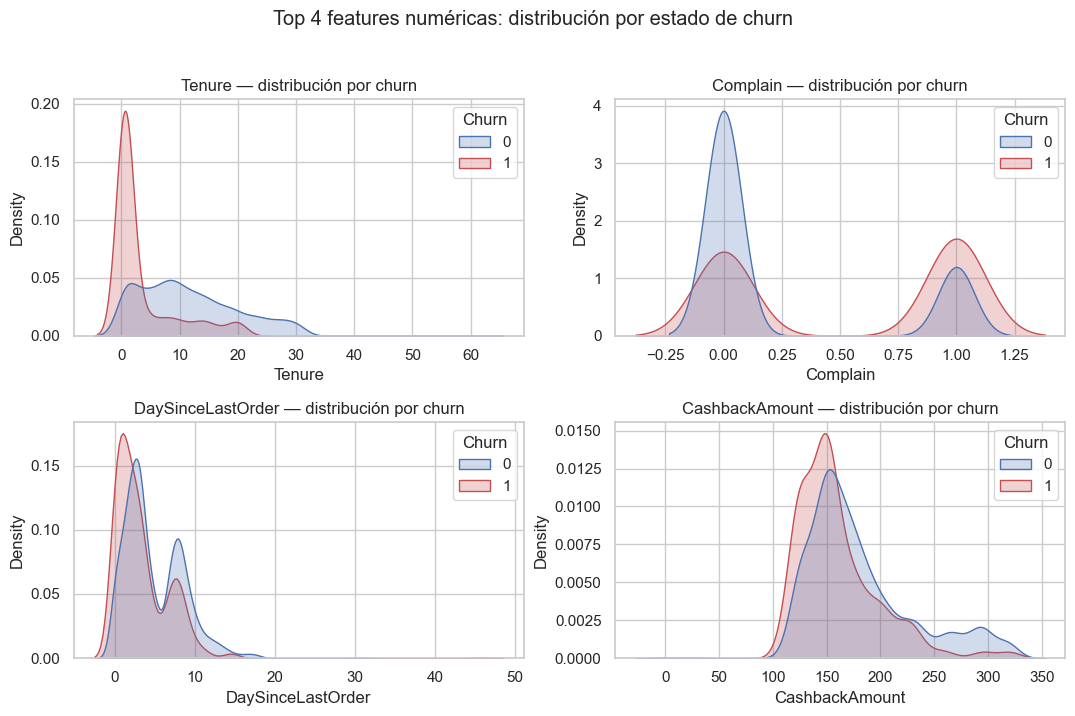

In [9]:
# Distribuciones del top 4 por |rank_biserial|, comparando churn vs no-churn
top_vars = (num_summary.assign(abs_rbc=num_summary["rank_biserial"].abs())
                       .sort_values("abs_rbc", ascending=False)["var"].head(4).tolist())
print("Top 4 features numéricas:", top_vars)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flatten(), top_vars):
    data = df.dropna(subset=[c])
    sns.kdeplot(data=data, x=c, hue=TARGET, common_norm=False, fill=True, ax=ax,
                palette={0: "#4C72B0", 1: "#C44E52"})
    ax.set_title(f"{c} — distribución por churn")
plt.suptitle("Top 4 features numéricas: distribución por estado de churn", y=1.02)
plt.show()


In [10]:
# Outliers IQR
out = []
for c in num_cols:
    s = df[c].dropna()
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    out.append({"var": c, "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(df), 2),
                "min": s.min(), "p99": float(np.percentile(s, 99)), "max": s.max()})
pd.DataFrame(out).sort_values("pct_outliers", ascending=False)


,var,n_outliers,pct_outliers,min,p99,max
10,OrderCount,703,12.49,1.0,15.0000,16.00
9,CouponUsed,629,11.17,0.0,9.0000,16.00
12,CashbackAmount,438,7.78,0.0,318.7431,324.99
4,NumberOfDeviceRegistered,397,7.05,1.0,6.0000,6.00
11,DaySinceLastOrder,62,1.10,0.0,15.0000,46.00
8,OrderAmountHikeFromlastYear,33,0.59,11.0,25.0000,26.00
3,HourSpendOnApp,6,0.11,0.0,4.0000,5.00
0,Tenure,4,0.07,0.0,30.0000,61.00
6,NumberOfAddress,4,0.07,1.0,11.0000,22.00
2,WarehouseToHome,2,0.04,5.0,35.0000,127.00


**Lectura outliers.** La mayoría son colas largas naturales de variables de
conteo (`OrderCount`, `CouponUsed`, `CashbackAmount`) — no son errores.
**Casos a mirar:** `WarehouseToHome` tiene `max = 127 km` con p99 ≈ 40 →
revisar plausibilidad con el área.


## 4 · Features categóricas

In [11]:
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum()
    r, k = confusion.shape
    denom = n * (min(r - 1, k - 1) or 1)
    return float(np.sqrt(chi2 / denom)) if denom else float("nan")


rows = []
for c in CATEGORICAL_COLS:
    s = df[c].astype("string").fillna("__NA__")
    ct = pd.crosstab(s, df[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct.values)
    v = cramers_v(ct.values)
    rows.append({"var": c, "cardinalidad": s.nunique(),
                 "chi2_p": p, "cramers_v": round(v, 3),
                 "churn_top_cat": df.groupby(s)[TARGET].mean().idxmax(),
                 "churn_top_rate": round(df.groupby(s)[TARGET].mean().max() * 100, 2)})
pd.DataFrame(rows).sort_values("cramers_v", ascending=False)


,var,cardinalidad,chi2_p,cramers_v,churn_top_cat,churn_top_rate
3,PreferedOrderCat,5,3.119243e-61,0.226,Mobile Phone,27.40
4,MaritalStatus,3,1.073011e-41,0.183,Single,26.73
1,PreferredPaymentMode,5,1.497857e-10,0.096,COD,24.90
0,PreferredLoginDevice,2,1.477040e-04,0.051,Computer,19.83
2,Gender,2,3.082094e-02,0.029,Male,17.73


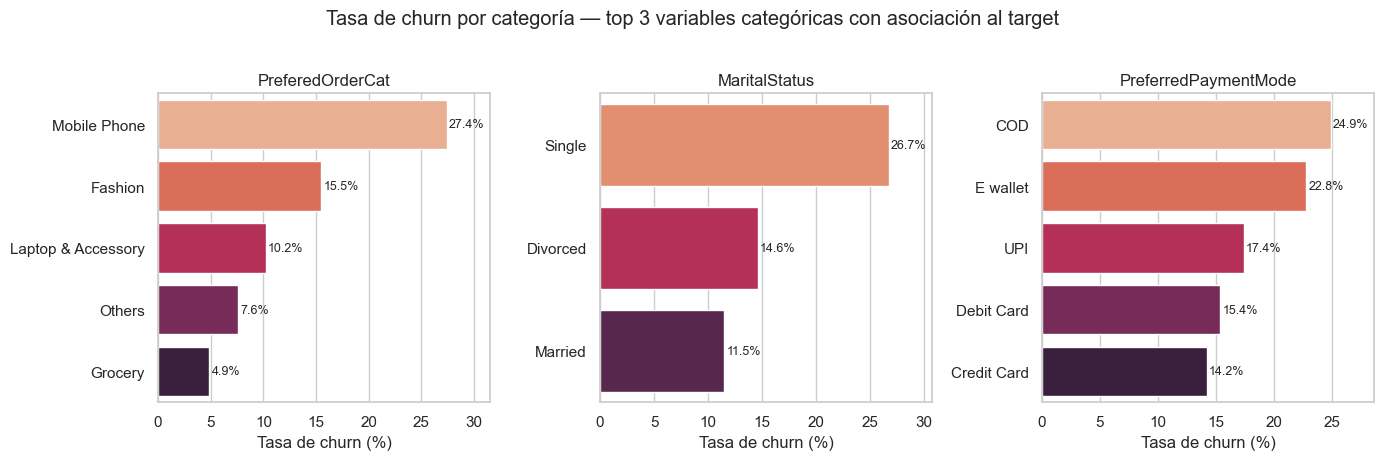

In [12]:
# Tasa de churn por categoría — top 3 features categóricas con mayor V
top_cat = ["PreferedOrderCat", "MaritalStatus", "PreferredPaymentMode"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, c in zip(axes, top_cat):
    rates = (df.groupby(c)[TARGET].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket_r")
    for i, v in enumerate(rates.values):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_xlim(0, max(rates) * 1.15)
    ax.set_title(f"{c}")
    ax.set_xlabel("Tasa de churn (%)")
    ax.set_ylabel("")
plt.suptitle("Tasa de churn por categoría — top 3 variables categóricas con asociación al target", y=1.02)
plt.show()


## 5 · Detección de leakage

In [13]:
# Correlación con el target (variables numéricas — point-biserial)
corr = (df[num_cols + [TARGET]].corr(numeric_only=True)[TARGET]
          .drop(TARGET).abs().sort_values(ascending=False))
print("Correlación absoluta con Churn (top):")
print(corr.round(3))
print()
print("¿Alguna |r| > 0.5? ->", (corr > 0.5).any())


Correlación absoluta con Churn (top):
Tenure                         0.349
Complain                       0.250
DaySinceLastOrder              0.161
CashbackAmount                 0.154
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
CityTier                       0.085
WarehouseToHome                0.077
NumberOfAddress                0.044
OrderCount                     0.029
HourSpendOnApp                 0.019
OrderAmountHikeFromlastYear    0.010
CouponUsed                     0.008
Name: Churn, dtype: float64

¿Alguna |r| > 0.5? -> False


In [14]:
# Foco en Complain: tasa de churn por bucket
churn_by_complain = df.groupby("Complain")[TARGET].agg(["mean", "size"]).rename(
    columns={"mean": "churn_rate"})
churn_by_complain["churn_rate"] *= 100
print(churn_by_complain.round(2))

ct = pd.crosstab(df["Complain"], df[TARGET])
chi2, p, _, _ = stats.chi2_contingency(ct.values)
print(f"\nChi-cuadrado Complain × Churn: chi2={chi2:.1f} · p={p:.2e}")
print(f"Cramér's V: {cramers_v(ct.values):.3f}")


          churn_rate  size
Complain                  
0              10.93  4026
1              31.67  1604

Chi-cuadrado Complain × Churn: chi2=350.9 · p=2.66e-78
Cramér's V: 0.250


**Veredicto leakage.**

- Ninguna variable tiene |r| > 0,5 con el target → no hay leakage masivo.
- **`Complain` es la única variable sospechosa** por mecanismo, no por número:
  el diccionario dice "queja del último mes" sin timestamp, y la diferencia
  de churn con/sin queja es +20,7 pp. Si la queja se registra al cancelar
  (no antes), `Complain` filtra el target.
- **Acción:** entrenar el modelo principal con `Complain` y un modelo de
  control sin ella. Reportar ambas métricas. Confirmar con negocio.


## 6 · Validación de las 5 hipótesis

### H1 · El riesgo de fuga se concentra en Tenure bajo

**Test:** Mann-Whitney U (unilateral) + Chi-cuadrado sobre buckets.


                 n  churn_rate  churn_rate_pct
TenureBucket                                  
0-1m          1198        0.52           51.84
2-3m           362        0.09            8.84
4-6m           590        0.07            7.46
7-12m         1320        0.06            5.68
13-24m        1467        0.06            6.48
>24m           429        0.00            0.00

Mann-Whitney U=3185639 · p=2.84e-193 · rank-biserial=-0.633
Chi-cuadrado buckets: chi2=1464.1 · p=0.00e+00 · Cramér's V=0.522


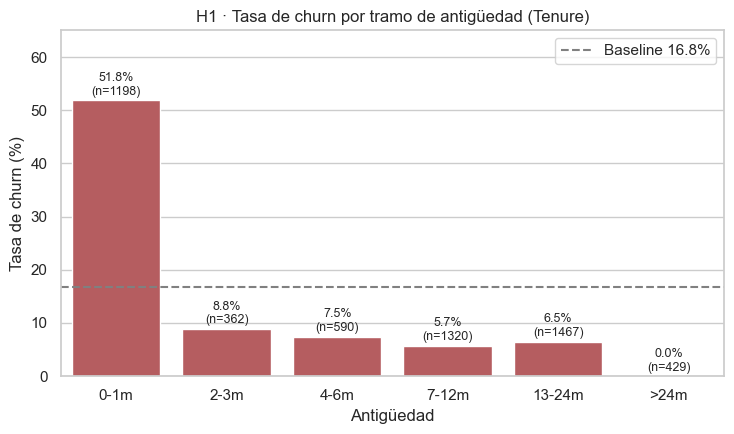

In [15]:
work = df.dropna(subset=["Tenure"]).copy()
bins = [-0.01, 1, 3, 6, 12, 24, work["Tenure"].max() + 0.01]
labels = ["0-1m", "2-3m", "4-6m", "7-12m", "13-24m", ">24m"]
work["TenureBucket"] = pd.cut(work["Tenure"], bins=bins, labels=labels, include_lowest=True)
g_h1 = work.groupby("TenureBucket", observed=True).agg(n=(TARGET, "size"), churn_rate=(TARGET, "mean"))
g_h1["churn_rate_pct"] = g_h1["churn_rate"] * 100
print(g_h1.round(2))

# Test
g0 = work.loc[work[TARGET] == 0, "Tenure"]
g1 = work.loc[work[TARGET] == 1, "Tenure"]
mw = stats.mannwhitneyu(g0, g1, alternative="greater")  # H1: tenure(no-churn) > tenure(churn)
rbc = 1 - 2 * mw.statistic / (len(g0) * len(g1))
ct = pd.crosstab(work["TenureBucket"], work[TARGET])
chi2, p_chi, _, _ = stats.chi2_contingency(ct.values)
print(f"\nMann-Whitney U={mw.statistic:.0f} · p={mw.pvalue:.2e} · rank-biserial={rbc:.3f}")
print(f"Chi-cuadrado buckets: chi2={chi2:.1f} · p={p_chi:.2e} · Cramér's V={cramers_v(ct.values):.3f}")

# Plot
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=g_h1.index.astype(str), y=g_h1["churn_rate_pct"], color="#C44E52", ax=ax)
for i, (p_, n) in enumerate(zip(g_h1["churn_rate_pct"].values, g_h1["n"].values)):
    ax.text(i, p_ + 0.5, f"{p_:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
ax.axhline(df[TARGET].mean() * 100, color="grey", linestyle="--",
           label=f"Baseline {df[TARGET].mean()*100:.1f}%")
ax.set_title("H1 · Tasa de churn por tramo de antigüedad (Tenure)")
ax.set_xlabel("Antigüedad"); ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, 65); ax.legend()
plt.show()


✅ **H1 CONFIRMADA con efecto grande.** Mann-Whitney p ≈ 10⁻¹⁹³, rank-biserial -0,63.
El primer mes concentra el 51,8% de churn; >24m cae a 0%.
**→ Para el modelo:** mantener `Tenure` numérica + crear `EsNuevo = (Tenure ≤ 1)`.


### H2 · Cliente nuevo + queja = combinación letal (interacción)

**Test:** Chi-cuadrado sobre las 4 combinaciones (Nuevo × Queja) + Fisher exacto (Nuevo+Queja vs resto).


   EsNuevo  Complain  mean  size  churn_pct
0        0         0  0.04  3081       3.57
1        0         1  0.13  1087      12.51
2        1         0  0.39   752      39.36
3        1         1  0.73   446      72.87

Chi-cuadrado 4 grupos: chi2=1728.8 · p=0.00e+00 · Cramér's V=0.568
Fisher (nuevo+queja vs resto): OR=21.7 · p=2.65e-178


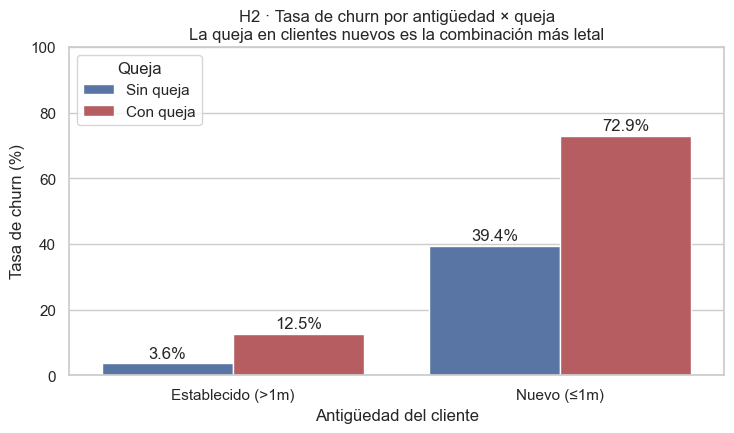

In [16]:
work = df.dropna(subset=["Tenure"]).copy()
work["EsNuevo"] = (work["Tenure"] <= 1).astype(int)

pivot = (work.groupby(["EsNuevo", "Complain"])[TARGET]
              .agg(["mean", "size"]).reset_index()
              .assign(churn_pct=lambda d: d["mean"] * 100))
print(pivot.round(2))

# Chi-cuadrado 4x2
work["grupo"] = work["EsNuevo"].astype(str) + "_" + work["Complain"].astype(str)
ct = pd.crosstab(work["grupo"], work[TARGET])
chi2, p, _, _ = stats.chi2_contingency(ct.values)
print(f"\nChi-cuadrado 4 grupos: chi2={chi2:.1f} · p={p:.2e} · Cramér's V={cramers_v(ct.values):.3f}")

# Fisher exacto: nuevo+queja vs resto
nq = ((work["EsNuevo"] == 1) & (work["Complain"] == 1))
a = int(((nq) & (work[TARGET] == 1)).sum())
b = int(((nq) & (work[TARGET] == 0)).sum())
c_ = int(((~nq) & (work[TARGET] == 1)).sum())
d_ = int(((~nq) & (work[TARGET] == 0)).sum())
or_, fp = stats.fisher_exact([[a, b], [c_, d_]], alternative="greater")
print(f"Fisher (nuevo+queja vs resto): OR={or_:.1f} · p={fp:.2e}")

# Plot
plot_df = pivot.copy()
plot_df["EsNuevo"] = plot_df["EsNuevo"].map({0: "Establecido (>1m)", 1: "Nuevo (≤1m)"})
plot_df["Complain"] = plot_df["Complain"].map({0: "Sin queja", 1: "Con queja"})
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(data=plot_df, x="EsNuevo", y="churn_pct", hue="Complain",
            palette=["#4C72B0", "#C44E52"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", padding=2)
ax.set_title("H2 · Tasa de churn por antigüedad × queja\nLa queja en clientes nuevos es la combinación más letal")
ax.set_xlabel("Antigüedad del cliente"); ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, 100); ax.legend(title="Queja")
plt.show()


✅ **H2 CONFIRMADA con efecto enorme.** OR = 21,7. Cramér's V = 0,57. Nuevo+Queja = 72,9%
de churn, contra 3,6% del establecido sin queja.
**→ Para el modelo:** crear `NuevoYQueja = EsNuevo & Complain`. **Operativo:**
toda queja en cliente con <30 días dispara alerta de retención inmediata.


### H3 · La satisfacción declarada NO protege a los nuevos (contraintuitiva)

**Test:** Chi-cuadrado + Spearman, restringido a clientes nuevos (Tenure ≤ 1).


Solo nuevos (Tenure ≤ 1):
                   mean  size  churn_pct
SatisfactionScore                       
1                  0.41   217      41.47
2                  0.41   116      41.38
3                  0.53   361      52.63
4                  0.53   202      52.97
5                  0.62   302      61.59

Chi-cuadrado (nuevos): chi2=26.1 · p=3.00e-05 · Cramér's V=0.148
Spearman ρ = 0.141 · p=9.74e-07
[Esperado si H3 cierta: ρ ≥ 0 (más score ≠ menos churn)]


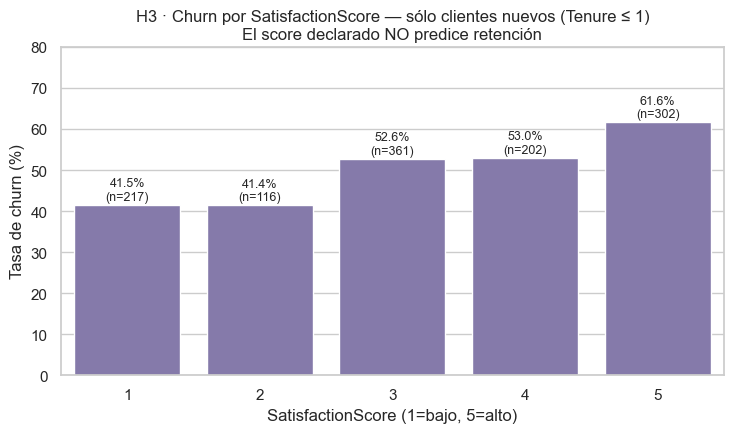

In [17]:
work = df.dropna(subset=["Tenure"]).copy()
work["EsNuevo"] = (work["Tenure"] <= 1).astype(int)
sub = work.loc[work["EsNuevo"] == 1].copy()

g_h3 = sub.groupby("SatisfactionScore")[TARGET].agg(["mean", "size"])
g_h3["churn_pct"] = g_h3["mean"] * 100
print("Solo nuevos (Tenure ≤ 1):")
print(g_h3.round(2))

ct = pd.crosstab(sub["SatisfactionScore"], sub[TARGET])
chi2, p, _, _ = stats.chi2_contingency(ct.values)
sp = stats.spearmanr(sub["SatisfactionScore"], sub[TARGET])
print(f"\nChi-cuadrado (nuevos): chi2={chi2:.1f} · p={p:.2e} · Cramér's V={cramers_v(ct.values):.3f}")
print(f"Spearman ρ = {sp.correlation:.3f} · p={sp.pvalue:.2e}")
print("[Esperado si H3 cierta: ρ ≥ 0 (más score ≠ menos churn)]")

# Plot
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=g_h3.index.astype(int), y=g_h3["churn_pct"], color="#8172B2", ax=ax)
for i, (p_, n) in enumerate(zip(g_h3["churn_pct"].values, g_h3["size"].values)):
    ax.text(i, p_ + 0.5, f"{p_:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
ax.set_title("H3 · Churn por SatisfactionScore — sólo clientes nuevos (Tenure ≤ 1)\nEl score declarado NO predice retención")
ax.set_xlabel("SatisfactionScore (1=bajo, 5=alto)")
ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, 80)
plt.show()


✅ **H3 CONFIRMADA y contraintuitiva.** Spearman ρ = **+0,14** (p ≈ 10⁻⁶):
score más alto correlaciona con MÁS churn en nuevos (score 5 = 61,6% vs score 1 = 41,5%).
**→ Para el modelo:** conservar la variable, ojo con el signo. **Para el negocio:**
no usar el score como termómetro; revisar cómo/cuándo se mide.


### H4 · CityTier 2/3 + queja peor que Tier 1 + queja (interacción)

**Test:** Chi-cuadrado global sobre los 6 grupos (Tier × Queja) + Chi-cuadrado
focalizado comparando Tier 2/3 con queja vs Tier 1 con queja.


   CityTier  Complain  churn_rate  size  churn_pct
0         1         0        0.09  2622       9.00
1         1         1        0.28  1044      28.35
2         2         0        0.16   180      15.56
3         2         1        0.32    62      32.26
4         3         0        0.14  1224      14.38
5         3         1        0.39   498      38.55



Chi global (6 grupos): chi2=397.6 · p=9.77e-84 · V=0.266
Chi focalizado (Tier 2/3 con queja vs Tier 1 con queja): chi2=1.83 · p=0.176 · V=0.068
n Tier 2/3 con queja: 560 · n Tier 1 con queja: 1044


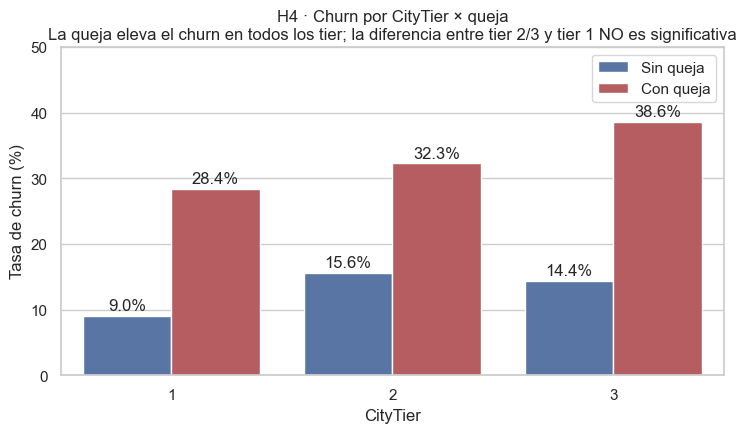

In [18]:
g_h4 = (df.groupby(["CityTier", "Complain"])[TARGET]
            .agg(["mean", "size"]).reset_index()
            .rename(columns={"mean": "churn_rate"}))
g_h4["churn_pct"] = g_h4["churn_rate"] * 100
print(g_h4.round(2))

# Chi global
df_tmp = df.copy()
df_tmp["grupo"] = df_tmp["CityTier"].astype(str) + "_" + df_tmp["Complain"].astype(str)
ct = pd.crosstab(df_tmp["grupo"], df_tmp[TARGET])
chi2, p_global, _, _ = stats.chi2_contingency(ct.values)
print(f"\nChi global (6 grupos): chi2={chi2:.1f} · p={p_global:.2e} · V={cramers_v(ct.values):.3f}")

# Chi focalizado: Tier 2/3 con queja vs Tier 1 con queja
a = df.loc[(df["CityTier"].isin([2, 3])) & (df["Complain"] == 1), TARGET]
b = df.loc[(df["CityTier"] == 1) & (df["Complain"] == 1), TARGET]
tbl = pd.crosstab(pd.Series(["t23"] * len(a) + ["t1"] * len(b), name="zona"),
                  pd.concat([a, b]))
chi2b, pb, _, _ = stats.chi2_contingency(tbl.values)
print(f"Chi focalizado (Tier 2/3 con queja vs Tier 1 con queja): chi2={chi2b:.2f} · p={pb:.3f} · V={cramers_v(tbl.values):.3f}")
print(f"n Tier 2/3 con queja: {len(a)} · n Tier 1 con queja: {len(b)}")

# Plot
g_h4["Complain_lbl"] = g_h4["Complain"].map({0: "Sin queja", 1: "Con queja"})
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(data=g_h4, x="CityTier", y="churn_pct", hue="Complain_lbl",
            palette=["#4C72B0", "#C44E52"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", padding=2)
ax.set_title("H4 · Churn por CityTier × queja\nLa queja eleva el churn en todos los tier; la diferencia entre tier 2/3 y tier 1 NO es significativa")
ax.set_xlabel("CityTier"); ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, 50); ax.legend(title="")
plt.show()


⚠️ **H4 PARCIALMENTE CONFIRMADA.** El efecto global tier×queja es contundente
(p < 10⁻⁸³), pero la comparación específica **tier 2/3 + queja vs tier 1 + queja
no es significativa al α = 0,05** (p = 0,176). El patrón visual existe (38,6%
vs 28,4%) pero con esta muestra entra en el ruido.
**→ Para el modelo:** conservar `CityTier` y `Complain` por separado (las dos
tienen señal). **Para el reporte ejecutivo:** no afirmar que la queja "pega
más fuerte" en el interior; sí decir que tier 2/3 churnea más y la queja
triplica el riesgo en cualquier tier.


### H5 · Más dispositivos registrados = más churn (contraintuitiva)

**Test:** Chi-cuadrado + Spearman + Mann-Whitney unilateral.


   NumberOfDeviceRegistered  mean  size  churn_pct
0                         1  0.09   235       9.36
1                         2  0.09   276       9.42
2                         3  0.15  1699      14.95
3                         4  0.16  2377      16.49
4                         5  0.22   881      22.47
5                         6  0.35   162      34.57

Chi: chi2=81.1 · p=4.92e-16 · V=0.120
Spearman ρ = 0.101 · p=2.65e-14
Mann-Whitney p (unilateral) = 1.53e-14 · rank-biserial = 0.148
[Esperado si H5 cierta: ρ > 0]


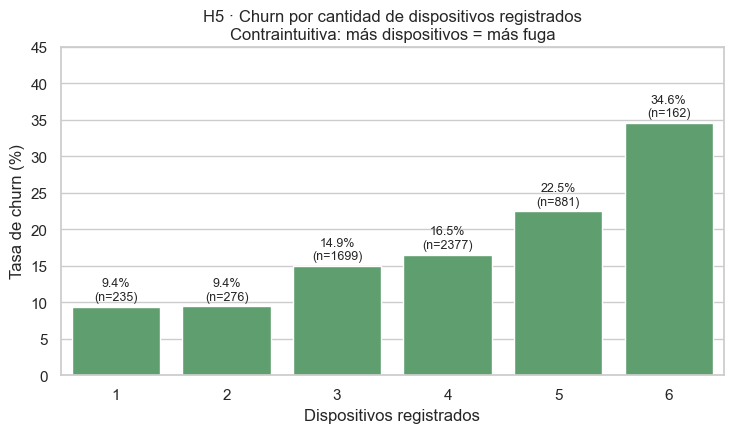

In [19]:
g_h5 = df.groupby("NumberOfDeviceRegistered")[TARGET].agg(["mean", "size"]).reset_index()
g_h5["churn_pct"] = g_h5["mean"] * 100
print(g_h5.round(2))

ct = pd.crosstab(df["NumberOfDeviceRegistered"], df[TARGET])
chi2, p, _, _ = stats.chi2_contingency(ct.values)
sp = stats.spearmanr(df["NumberOfDeviceRegistered"], df[TARGET])
mw = stats.mannwhitneyu(df.loc[df[TARGET] == 0, "NumberOfDeviceRegistered"],
                        df.loc[df[TARGET] == 1, "NumberOfDeviceRegistered"],
                        alternative="less")
rbc = 1 - 2 * mw.statistic / (len(df[df[TARGET] == 0]) * len(df[df[TARGET] == 1]))
print(f"\nChi: chi2={chi2:.1f} · p={p:.2e} · V={cramers_v(ct.values):.3f}")
print(f"Spearman ρ = {sp.correlation:.3f} · p={sp.pvalue:.2e}")
print(f"Mann-Whitney p (unilateral) = {mw.pvalue:.2e} · rank-biserial = {rbc:.3f}")
print("[Esperado si H5 cierta: ρ > 0]")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(x=g_h5["NumberOfDeviceRegistered"].astype(int), y=g_h5["churn_pct"],
            color="#55A868", ax=ax)
for i, (p_, n) in enumerate(zip(g_h5["churn_pct"].values, g_h5["size"].values)):
    ax.text(i, p_ + 0.5, f"{p_:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
ax.set_title("H5 · Churn por cantidad de dispositivos registrados\nContraintuitiva: más dispositivos = más fuga")
ax.set_xlabel("Dispositivos registrados"); ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, 45)
plt.show()


✅ **H5 CONFIRMADA y contraintuitiva.** ρ = +0,10 (p ≈ 10⁻¹⁴). 1-2 dispositivos
≈ 9% churn; 6 dispositivos = 34,6%. El efecto es modesto pero monotónico.
**→ Para el modelo:** conservar la variable. **Para el negocio:** investigar
el cluster de 5-6 dispositivos como cohorte específica (¿cuentas compartidas?
¿shopping around? ¿problemas técnicos que generan re-registros?).


## 7 · Gráficos adicionales pedidos por negocio

### 7.1 · ¿En qué momento del tenure se concentra el churn?

% acumulado de churners al mes 1: 71.6%
% acumulado de churners al mes 6: 80.4%


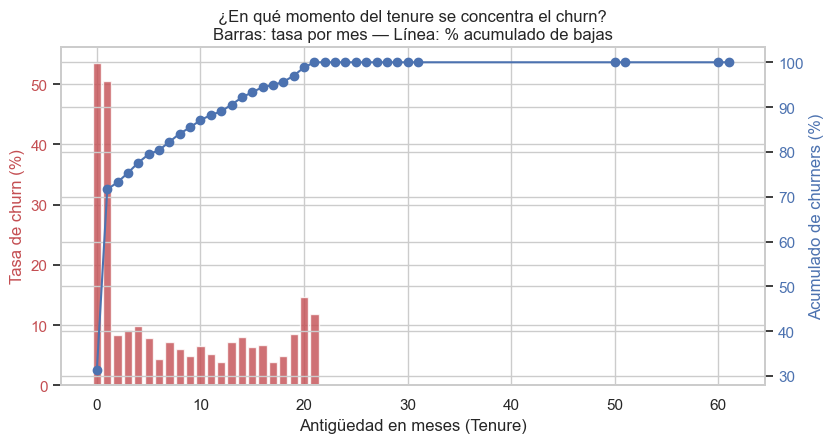

In [20]:
work = df.dropna(subset=["Tenure"]).copy()
g_tc = (work.groupby("Tenure")[TARGET]
            .agg(["sum", "size"]).rename(columns={"sum": "churns", "size": "n"}))
g_tc["churn_pct"] = (g_tc["churns"] / g_tc["n"] * 100).round(2)
g_tc["cum_churn_share"] = (g_tc["churns"].cumsum() / g_tc["churns"].sum() * 100).round(2)

cum1 = g_tc.loc[g_tc.index <= 1, "churns"].sum() / g_tc["churns"].sum() * 100
cum6 = g_tc.loc[g_tc.index <= 6, "churns"].sum() / g_tc["churns"].sum() * 100
print(f"% acumulado de churners al mes 1: {cum1:.1f}%")
print(f"% acumulado de churners al mes 6: {cum6:.1f}%")

fig, ax1 = plt.subplots(figsize=(8.5, 4.6))
ax1.bar(g_tc.index, g_tc["churn_pct"], color="#C44E52", alpha=0.8, label="% churn dentro del mes")
ax1.set_xlabel("Antigüedad en meses (Tenure)")
ax1.set_ylabel("Tasa de churn (%)", color="#C44E52")
ax1.tick_params(axis="y", labelcolor="#C44E52")
ax2 = ax1.twinx()
ax2.plot(g_tc.index, g_tc["cum_churn_share"], color="#4C72B0", marker="o",
         label="% acumulado de churners")
ax2.set_ylabel("Acumulado de churners (%)", color="#4C72B0")
ax2.tick_params(axis="y", labelcolor="#4C72B0")
plt.title("¿En qué momento del tenure se concentra el churn?\nBarras: tasa por mes — Línea: % acumulado de bajas")
plt.show()


### 7.2 · Top 10 segmentos por mayor riesgo (CityTier × Queja × Nuevo)

   CityTier  Complain  EsNuevo     n  churn_pct
0         1         1        1   274      72.63
1         3         1        1   156      70.51
2         2         0        1    30      66.67
3         3         0        1   252      47.62
4         1         0        1   470      33.19
5         3         1        0   322      21.12
6         1         1        0   725       9.38
7         3         0        0   948       4.85
8         2         0        0   132       3.03
9         1         0        0  2001       3.00


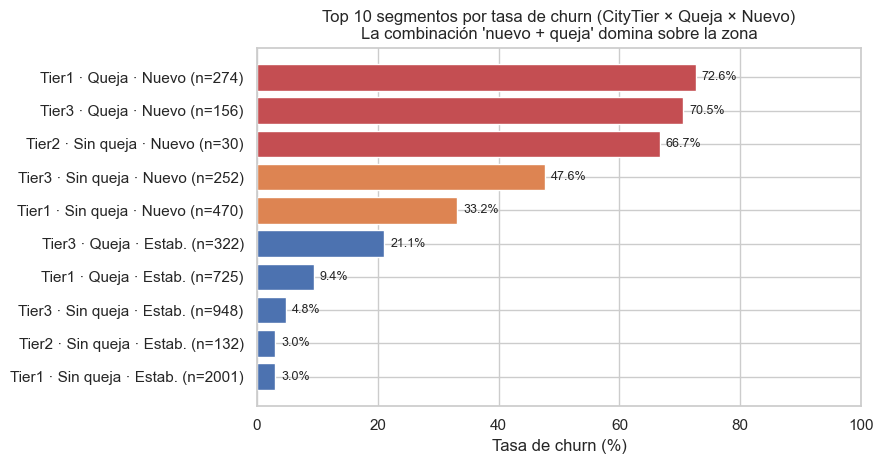

In [21]:
work = df.dropna(subset=["Tenure"]).copy()
work["EsNuevo"] = (work["Tenure"] <= 1).astype(int)
grid = []
for tier in [1, 2, 3]:
    for q in [0, 1]:
        for nv in [0, 1]:
            sub = work[(work["CityTier"] == tier) & (work["Complain"] == q) & (work["EsNuevo"] == nv)]
            if len(sub) >= 30:
                grid.append({"CityTier": tier, "Complain": q, "EsNuevo": nv,
                             "n": int(len(sub)),
                             "churn_pct": round(sub[TARGET].mean() * 100, 2)})
top = sorted(grid, key=lambda r: r["churn_pct"], reverse=True)[:10]
top_df = pd.DataFrame(top)
print(top_df)

labels = [f"Tier{r['CityTier']} · {'Queja' if r['Complain'] else 'Sin queja'} · {'Nuevo' if r['EsNuevo'] else 'Estab.'} (n={r['n']})" for r in top]
vals = [r["churn_pct"] for r in top]
colors = ["#C44E52" if v >= 50 else "#DD8452" if v >= 30 else "#4C72B0" for v in vals]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(labels[::-1], vals[::-1], color=colors[::-1])
for i, v in enumerate(vals[::-1]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_title("Top 10 segmentos por tasa de churn (CityTier × Queja × Nuevo)\nLa combinación 'nuevo + queja' domina sobre la zona")
ax.set_xlabel("Tasa de churn (%)"); ax.set_xlim(0, 100)
plt.show()


### 7.3 · ¿El cashback retiene o no?

                    mean  size  churn_pct
CashbackAmount                           
(-0.001, 140.804]   0.27  1126      26.64
(140.804, 153.654]  0.22  1126      22.38
(153.654, 173.066]  0.13  1126      12.61
(173.066, 208.814]  0.14  1126      13.68
(208.814, 324.99]   0.09  1126       8.88

Spearman ρ = -0.173 · p=7.16e-39
Mann-Whitney p = 2.52e-38
Promedio cashback   no-churn: $180.64 · churn: $160.37


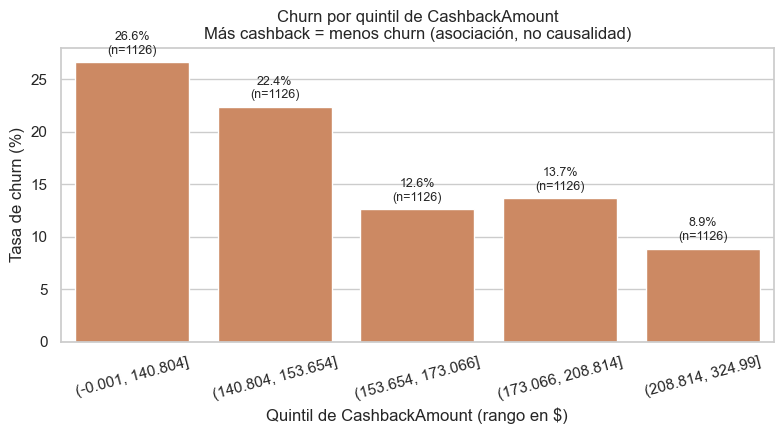

In [22]:
cb_bins = pd.qcut(df["CashbackAmount"], q=5, duplicates="drop")
cb = df.groupby(cb_bins, observed=True)[TARGET].agg(["mean", "size"])
cb["churn_pct"] = cb["mean"] * 100
print(cb.round(2))

sp = stats.spearmanr(df["CashbackAmount"], df[TARGET])
g0 = df.loc[df[TARGET] == 0, "CashbackAmount"]
g1 = df.loc[df[TARGET] == 1, "CashbackAmount"]
mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
print(f"\nSpearman ρ = {sp.correlation:.3f} · p={sp.pvalue:.2e}")
print(f"Mann-Whitney p = {mw.pvalue:.2e}")
print(f"Promedio cashback   no-churn: ${g0.mean():.2f} · churn: ${g1.mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=[str(i) for i in cb.index], y=cb["churn_pct"].values, color="#DD8452", ax=ax)
for i, (p_, n) in enumerate(zip(cb["churn_pct"].values, cb["size"].values)):
    ax.text(i, p_ + 0.5, f"{p_:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
ax.set_title("Churn por quintil de CashbackAmount\nMás cashback = menos churn (asociación, no causalidad)")
ax.set_xlabel("Quintil de CashbackAmount (rango en $)")
ax.set_ylabel("Tasa de churn (%)")
plt.setp(ax.get_xticklabels(), rotation=15)
plt.show()


**Lectura sobre cashback.** Asociación monotónica clara: Q1 = 26,6% churn vs
Q5 = 8,9%. Pero **asociación ≠ causalidad**: el cliente que recibe más
cashback probablemente ya es más activo/leal. Para afirmar "subir cashback
retiene", haría falta un experimento A/B. Para el modelo, es un buen
predictor; para el reporte ejecutivo, hay que matizar el lenguaje.


## 8 · Conclusiones · Próximo paso

**Verdict de las 5 hipótesis** (tabla resumen — ver `reports/hipotesis.md` para detalle).

| Hip. | Resultado | Tamaño de efecto |
|---|---|---|
| H1 — Tenure bajo → más churn | ✅ Confirmada | Grande (rank-bis = -0,63) |
| H2 — Nuevo + queja → desproporción | ✅ Confirmada | Grande (OR = 21,7) |
| H3 — Score alto NO protege a nuevos | ✅ Confirmada (contraintuitiva) | Pequeño-medio (V = 0,15) |
| H4 — Tier 2/3 + queja peor que Tier 1 + queja | ⚠️ Parcialmente | Global medio, focal NO significativo (p=0,18) |
| H5 — Más dispositivos = más churn | ✅ Confirmada (contraintuitiva) | Pequeño-medio (V = 0,12) |

**Variables a llevar al modelo:** todas las features salvo `CustomerID`. Crear
`EsNuevo = (Tenure ≤ 1)` y `NuevoYQueja = EsNuevo & Complain` como banderas
explícitas.

**Variables con caveat:** `Complain` (leakage potencial), `DaySinceLastOrder`
(signo contraintuitivo — pedir definición al área).

**Variables sin señal (mantener pero esperar poco):** `HourSpendOnApp`,
`CouponUsed`, `OrderAmountHikeFromlastYear`.

**Métrica recomendada:** **Recall** + PR-AUC. Accuracy descartada
explícitamente.

**Próximo paso (notebook `02_modelado.ipynb`):**
1. Split estratificado `train_test_split(test_size=0.2, stratify=y, random_state=42)`.
2. Pipeline con `SimpleImputer(strategy='median')` + `OneHotEncoder` para nominales.
3. Baseline `DummyClassifier(strategy='most_frequent')`.
4. Árbol de decisión + Random Forest, ambos con `class_weight='balanced'`.
5. Cross-validation estratificada k=5.
6. Reportar recall, precision, F1, PR-AUC, ROC-AUC, matriz de confusión.
7. Comparativa con y sin `Complain`.

Detalle completo en `reports/handoff_to_modeler.md`.
